# Task 2 — Step 3: DANN — Adversarial Alignment with Gradient Reversal

DANN (Ganin et al., 2016) replaces the explicit discrepancy with a **domain discriminator** $D$ on the same 512-d feature: Linear(512→256) → ReLU → Dropout(0.5) → Linear(256→2). $D$ is trained to separate pooled source ($d=0$) from target ($d=1$); a **gradient-reversal layer** (identity forward, $-\alpha\,\partial/\partial f$ backward) makes the backbone maximise the same loss:
$$\min_{F,C}\max_{D}\;\mathcal{L}_{\text{cls}}(C(F(x_s)),y_s)\;-\;\mathcal{L}_{d}\big(D(F(x)),d\big),\qquad \alpha(p)=\frac{2}{1+e^{-10p}}-1$$
where $p=\text{step}/\text{total steps of the `MAX_EPOCHS` (= 30) epoch budget}$. Loss weight 1. Only source examples enter $\mathcal{L}_{\text{cls}}$; source and target both enter $\mathcal{L}_d$.

### What was wrong with the previous DANN run (26.2% Sketch, −30.7 pp)
Checking the old checkpoint **without target labels** showed that it assigned **86% of Sketch images to one class** (giraffe). The target feature norm (32) had also moved *further* from the source norm (73). The earlier implementation L2-normalised features before $D$ and clamped $D$'s logits, so $D$ saw only feature *directions*. The linear classifier, however, uses the raw features, norm included. Adversarial training therefore aligned directions while the norm gap grew, and target predictions collapsed.

Removing the normalisation, i.e. following the manual and feeding the raw 512-d feature, exposes the instability the normalisation had been hiding. With one AdamW at 1e-4 for everything, a probe run diverged at α≈0.1 (feature norms 10⁵–10⁷, classification loss > 10³). The backbone can inflate the loss of a ReLU discriminator without bound by scaling features up, and the small discriminator cannot keep pace with an 11M-parameter backbone.

**Fix (label-free, spec-compatible):** raw features, no clamping, no gradient clipping. The discriminator gets its own AdamW parameter group at **10× the base learning rate** (1e-3), the standard treatment of the newly added adversarial head in the DANN/CDAN reference code. The backbone and classifier keep AdamW(1e-4, 1e-4) like every other method. The choice was made from training losses, feature norms and target *prediction* histograms only; no Sketch labels were used. CDAN uses the identical setting. 

**Second stabiliser (added after a full run diverged).** With the 10× discriminator lr alone, the full DANN run still blew up once α passed ≈0.6 (epoch 3: classification loss 553, feature norm ≈6·10⁴, then every Sketch image predicted as one class). A ReLU discriminator's logits grow with the feature scale, so the backbone can keep raising the reversed domain loss by inflating *all* features. Fix: the discriminator receives $F(x)/s$, where $s$ is the joint batch's mean feature norm with no gradient through it. Uniform inflation then changes nothing D sees, and the reversed gradient shrinks as the scale grows. Unlike the old per-image L2 normalisation, relative source/target norm differences stay visible. Gradient-norm clipping (1.0) is also applied. The classifier still uses the raw feature. A stress test ramping α to 1 kept the discriminator in a real contest (accuracy 26–74%, loss ≈ ln 2) with no divergence. Clamping D's logits was tried first and rejected: it zeroes D's gradient once saturated, and D died at exactly 50%.

In [1]:
%matplotlib inline
import os, sys, json, math
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from shared.src.seed import set_seed, SEED
from shared.src.pacs_data import PACSDataset, get_pacs_dataloaders, PACS_SOURCE_DOMAINS, PACS_CLASSES
from shared.src.pacs_protocol import freeze_bn_stats, MAX_EPOCHS, PATIENCE
from shared.src.losses import compute_mmd
from shared.src.plotting import use_style, SEQ_CMAP, DIV_CMAP, PALETTE, DOMAIN_COLORS, NEUTRAL, INK_2, color_of, save_show
from task2_domain_adaptation.src.backbone import ResNet18Backbone
from task2_domain_adaptation.src.discriminator import DomainDiscriminator
from task2_domain_adaptation.src.train import train_uda, grl_alpha, cdan_features
from task2_domain_adaptation.src.evaluate import evaluate_source_validation, evaluate_target

use_style()
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = os.path.join(ROOT, 'data', 'PACS')
SPLIT = os.path.join(ROOT, 'shared', 'splits', 'pacs_sketch_seed6304.json')
CKPT = os.path.join(ROOT, 'task2_domain_adaptation', 'checkpoints')
RES = os.path.join(ROOT, 'task2_domain_adaptation', 'results')
os.makedirs(CKPT, exist_ok=True); os.makedirs(RES, exist_ok=True)
print(f"device={device} | seed={SEED}")

device=cuda | seed=6304


## 1. Data
Each update: 8 labeled images from each source domain (24) + 24 **unlabeled** Sketch images. The target train loader yields `(image, label)` pairs because it wraps the same folder dataset, but the training loop discards the label (`x_t, _ = ...`).

In [2]:
src_train, src_val, tgt_train, tgt_eval = get_pacs_dataloaders(DATA, SPLIT, source_batch_size=8, target_batch_size=24, eval_batch_size=64)
print({d: len(l.dataset) for d, l in src_train.items()}, '| sketch (unlabeled):', len(tgt_train.dataset))
print('steps/epoch =', max(len(l) for l in src_train.values()), '(largest source domain; smaller loaders and the target loader are cycled)')

{'photo': 1336, 'art_painting': 1638, 'cartoon': 1875} | sketch (unlabeled): 3929
steps/epoch = 234 (largest source domain; smaller loaders and the target loader are cycled)


## 2. Gradient-reversal schedule over the training budget

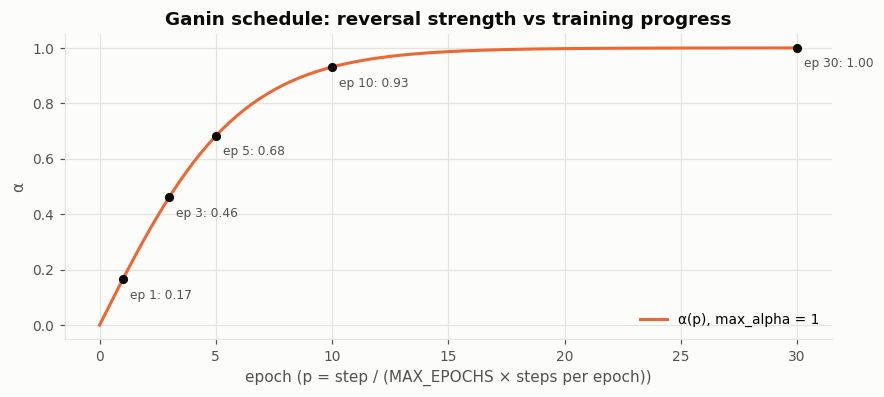

In [3]:
steps_per_epoch = max(len(l) for l in src_train.values()); total = MAX_EPOCHS * steps_per_epoch
p = np.linspace(0, 1, 300)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(p * MAX_EPOCHS, [grl_alpha(v) for v in p], color=color_of('DANN'), label='α(p), max_alpha = 1')
for e in [1, 3, 5, 10, MAX_EPOCHS]:
    ax.plot(e, grl_alpha(e / MAX_EPOCHS), 'o', color='#0b0b0b', ms=5); ax.text(e + 0.3, grl_alpha(e / MAX_EPOCHS) - 0.07, f'ep {e}: {grl_alpha(e/MAX_EPOCHS):.2f}', fontsize=8, color=INK_2)
ax.set_xlabel('epoch (p = step / (MAX_EPOCHS × steps per epoch))'); ax.set_ylabel('α'); ax.set_title('Ganin schedule: reversal strength vs training progress'); ax.legend(loc='lower right')
save_show(fig, os.path.join(RES, 'dann_grl_schedule.png'))

## 3. Train DANN
Selection uses **only** mean source-validation macro-F1 (patience 5, ≤ 30 epochs (budget: `MAX_EPOCHS` / `PATIENCE` in `shared/src/pacs_protocol.py` = 30 / 5, as the manual specifies)). Set `FORCE_TRAIN = False` to reload.

In [4]:
FORCE_TRAIN = True
ckpt_path = os.path.join(CKPT, 'dann.pth')
hist_path = os.path.join(CKPT, 'dann_history.json')
CONFIG = dict(method='dann', max_alpha=1.0, disc_lr_mult=10.0, grad_clip=1.0, disc_input='F(x) / detached batch-mean norm', lr=1e-4, wd=1e-4, max_epochs=MAX_EPOCHS, patience=PATIENCE, disc='512-256-ReLU-Dropout0.5-2', seed=SEED)
TRAIN_KW = {'method', 'max_alpha', 'disc_lr_mult', 'grad_clip', 'lr', 'wd', 'max_epochs', 'patience'}

if FORCE_TRAIN or not os.path.exists(ckpt_path):
    set_seed(SEED)
    model = ResNet18Backbone(num_classes=7)
    discriminator = DomainDiscriminator(512, hidden_dim=256, dropout=0.5)
    out = train_uda(model, src_train, src_val, device, target_loader=tgt_train, discriminator=discriminator, save_path=ckpt_path, **{k: v for k, v in CONFIG.items() if k in TRAIN_KW})
    history, best_epoch, best_f1 = out['history'], out['best_epoch'], out['best_f1']
    json.dump({'config': CONFIG, 'history': history, 'best_epoch': best_epoch, 'best_f1': best_f1}, open(hist_path, 'w'), indent=1)
else:
    meta = json.load(open(hist_path)); history, best_epoch, best_f1 = meta['history'], meta['best_epoch'], meta['best_f1']
model = ResNet18Backbone(num_classes=7).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
print(f"selected epoch {best_epoch} | mean source-val macro-F1 {best_f1:.4f}")

[dann] ep  1 | cls 0.516 | dom 0.644 acc 0.62 | alpha 0.17 | |f_s| 55.9 |f_t| 78.6 | tgt max-class 0.24 | val F1 0.8629 *
[dann] ep  2 | cls 0.244 | dom 0.682 acc 0.54 | alpha 0.32 | |f_s| 60.2 |f_t| 49.9 | tgt max-class 0.23 | val F1 0.9111 *
[dann] ep  3 | cls 0.209 | dom 0.683 acc 0.55 | alpha 0.46 | |f_s| 61.3 |f_t| 57.9 | tgt max-class 0.18 | val F1 0.9095
[dann] ep  4 | cls 0.179 | dom 0.689 acc 0.51 | alpha 0.58 | |f_s| 92.4 |f_t| 88.5 | tgt max-class 0.17 | val F1 0.9111 *
[dann] ep  5 | cls 0.182 | dom 0.699 acc 0.47 | alpha 0.68 | |f_s| 187.7 |f_t| 327.1 | tgt max-class 0.23 | val F1 0.9239 *
[dann] ep  6 | cls 0.125 | dom 0.691 acc 0.51 | alpha 0.76 | |f_s| 211.7 |f_t| 216.7 | tgt max-class 0.22 | val F1 0.9240 *
[dann] ep  7 | cls 0.111 | dom 0.696 acc 0.49 | alpha 0.82 | |f_s| 182.9 |f_t| 204.2 | tgt max-class 0.19 | val F1 0.9263 *
[dann] ep  8 | cls 0.137 | dom 0.697 acc 0.48 | alpha 0.87 | |f_s| 333.4 |f_t| 363.7 | tgt max-class 0.32 | val F1 0.9175
[dann] ep  9 | cls 0

## 4. Did DANN train as intended? (label-free diagnostics)
Top row: classification loss, the alignment term, and the discriminator accuracy. Bottom row: source-validation macro-F1 per domain, mean feature norm for source vs target batches, and the share of target images assigned to each class. A healthy adaptation run keeps the classification loss low, keeps source-validation F1 stable, narrows the feature-norm gap, and **does not** push most target images into one class. None of these panels use Sketch labels.

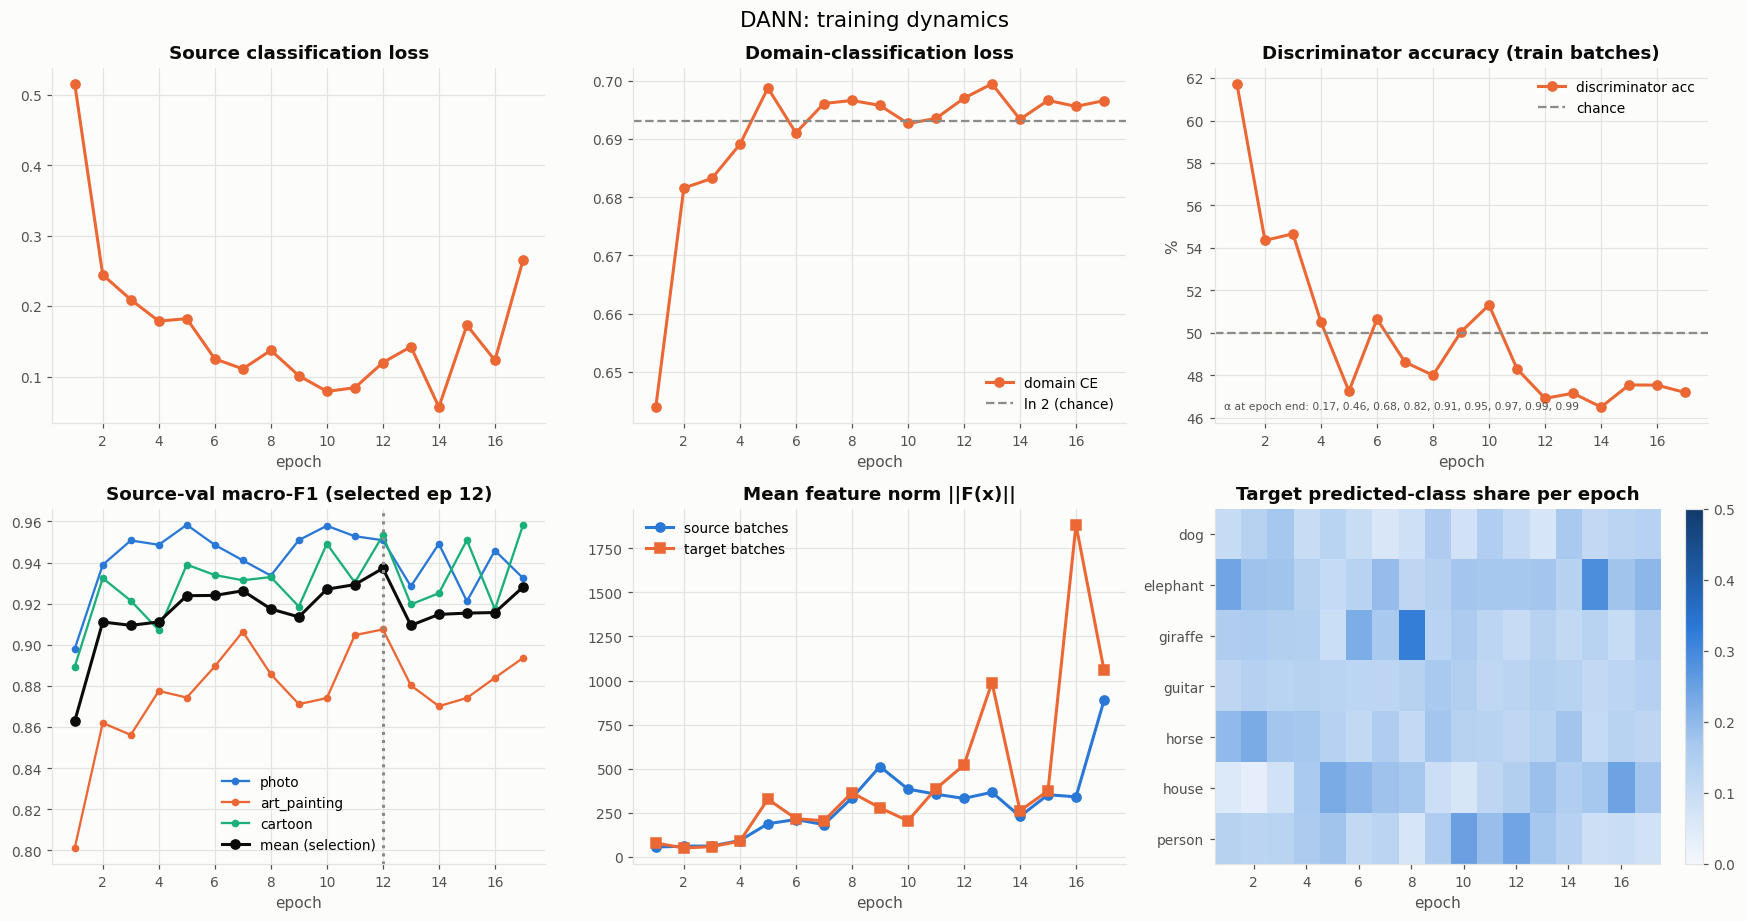

final-epoch target max-class share: 0.20 | at selected epoch: 0.24


In [5]:
H = history; ep = np.arange(1, len(H['cls_loss']) + 1)
fig, ax = plt.subplots(2, 3, figsize=(16, 8.5))
ax[0, 0].plot(ep, H['cls_loss'], 'o-', color=color_of('DANN'))
ax[0, 0].set_title('Source classification loss'); ax[0, 0].set_xlabel('epoch')
ax[0, 1].plot(ep, H['align_loss'], 'o-', color=color_of('DANN'), label='domain CE')
ax[0, 1].axhline(np.log(2), color=NEUTRAL, ls='--', lw=1.5, label='ln 2 (chance)'); ax[0, 1].set_title('Domain-classification loss'); ax[0, 1].legend(); ax[0, 1].set_xlabel('epoch')
ax[0, 2].plot(ep, 100 * np.array(H['dom_acc']), 'o-', color=color_of('DANN'), label='discriminator acc')
ax[0, 2].axhline(50, color=NEUTRAL, ls='--', lw=1.5, label='chance')
ax[0, 2].set_title('Discriminator accuracy (train batches)'); ax[0, 2].set_ylabel('%'); ax[0, 2].legend(); ax[0, 2].set_xlabel('epoch')
ax[0, 2].text(0.02, 0.04, 'α at epoch end: ' + ', '.join(f'{a:.2f}' for a in H['alpha'][::max(1, len(ep)//6)]), transform=ax[0, 2].transAxes, fontsize=7, color=INK_2)
for d in PACS_SOURCE_DOMAINS:
    ax[1, 0].plot(ep, H['val_per_domain'][d]['f1'], 'o-', ms=4, lw=1.5, color=DOMAIN_COLORS[d], label=d)
ax[1, 0].plot(ep, H['val_mean_f1'], 'o-', color='#0b0b0b', label='mean (selection)')
ax[1, 0].axvline(best_epoch, color=NEUTRAL, ls=':'); ax[1, 0].set_title(f'Source-val macro-F1 (selected ep {best_epoch})'); ax[1, 0].legend(); ax[1, 0].set_xlabel('epoch')
ax[1, 1].plot(ep, H['src_feat_norm'], 'o-', color=DOMAIN_COLORS['source'], label='source batches')
ax[1, 1].plot(ep, H['tgt_feat_norm'], 's-', color=DOMAIN_COLORS['target'], label='target batches')
ax[1, 1].set_title('Mean feature norm ||F(x)||'); ax[1, 1].legend(); ax[1, 1].set_xlabel('epoch')
share = np.array(H['tgt_pred_hist']).T
im = ax[1, 2].imshow(share, aspect='auto', cmap=SEQ_CMAP, vmin=0, vmax=max(0.5, share.max()), extent=[0.5, len(ep) + 0.5, 6.5, -0.5])
ax[1, 2].set_yticks(range(7)); ax[1, 2].set_yticklabels(PACS_CLASSES); ax[1, 2].grid(False)
ax[1, 2].set_title('Target predicted-class share per epoch'); ax[1, 2].set_xlabel('epoch'); fig.colorbar(im, ax=ax[1, 2], fraction=0.046)
fig.suptitle('DANN: training dynamics', fontsize=14); fig.tight_layout()
save_show(fig, os.path.join(RES, 'dann_training_curves.png'))
print(f"final-epoch target max-class share: {H['tgt_max_class_share'][-1]:.2f} | at selected epoch: {H['tgt_max_class_share'][best_epoch-1]:.2f}")

## 5. Source-validation results (locked checkpoint)

In [6]:
src_metrics = evaluate_source_validation(model, src_val, device)
tab = pd.DataFrame({d: {'acc (%)': 100 * src_metrics[d]['acc'], 'macro-F1 (%)': 100 * src_metrics[d]['f1']} for d in PACS_SOURCE_DOMAINS}).T
tab.loc['mean'] = [100 * src_metrics['mean_acc'], 100 * src_metrics['mean_f1']]
tab.loc['worst'] = tab.loc[PACS_SOURCE_DOMAINS].min()
tab.round(2)

,acc (%),macro-F1 (%)
photo,95.81,95.09
art_painting,90.49,90.75
cartoon,94.88,95.32
mean,93.73,93.72
worst,90.49,90.75


## 6. Target (Sketch) evaluation
Configuration and checkpoint are fixed above; Sketch labels are used here only to measure the result.

In [7]:
tgt = evaluate_target(model, tgt_eval, device)
so = pd.read_csv(os.path.join(RES, 'source_only_summary.csv'), index_col=0).iloc[0]
delta = 100 * (tgt['acc'] - so['Target (Sketch) Acc'])
print(f"Sketch acc {100*tgt['acc']:.2f}% | macro-F1 {100*tgt['f1']:.2f}% | change vs Source-only {delta:+.2f} pp")
summary = pd.DataFrame([{
    'Photo Val Acc': src_metrics['photo']['acc'], 'Art Val Acc': src_metrics['art_painting']['acc'], 'Cartoon Val Acc': src_metrics['cartoon']['acc'],
    'Photo Val F1': src_metrics['photo']['f1'], 'Art Val F1': src_metrics['art_painting']['f1'], 'Cartoon Val F1': src_metrics['cartoon']['f1'],
    'Mean Source Val Acc': src_metrics['mean_acc'], 'Mean Source Val F1': src_metrics['mean_f1'],
    'Target (Sketch) Acc': tgt['acc'], 'Target (Sketch) F1': tgt['f1'], 'Delta Target Acc': delta / 100}], index=['DANN'])
summary.to_csv(os.path.join(RES, 'dann_summary.csv'))
summary.T.round(4)

Sketch acc 45.76% | macro-F1 49.99% | change vs Source-only -13.46 pp


,DANN
Photo Val Acc,0.9581
Art Val Acc,0.9049
Cartoon Val Acc,0.9488
Photo Val F1,0.9509
Art Val F1,0.9075
Cartoon Val F1,0.9532
Mean Source Val Acc,0.9373
Mean Source Val F1,0.9372
Target (Sketch) Acc,0.4576
Target (Sketch) F1,0.4999


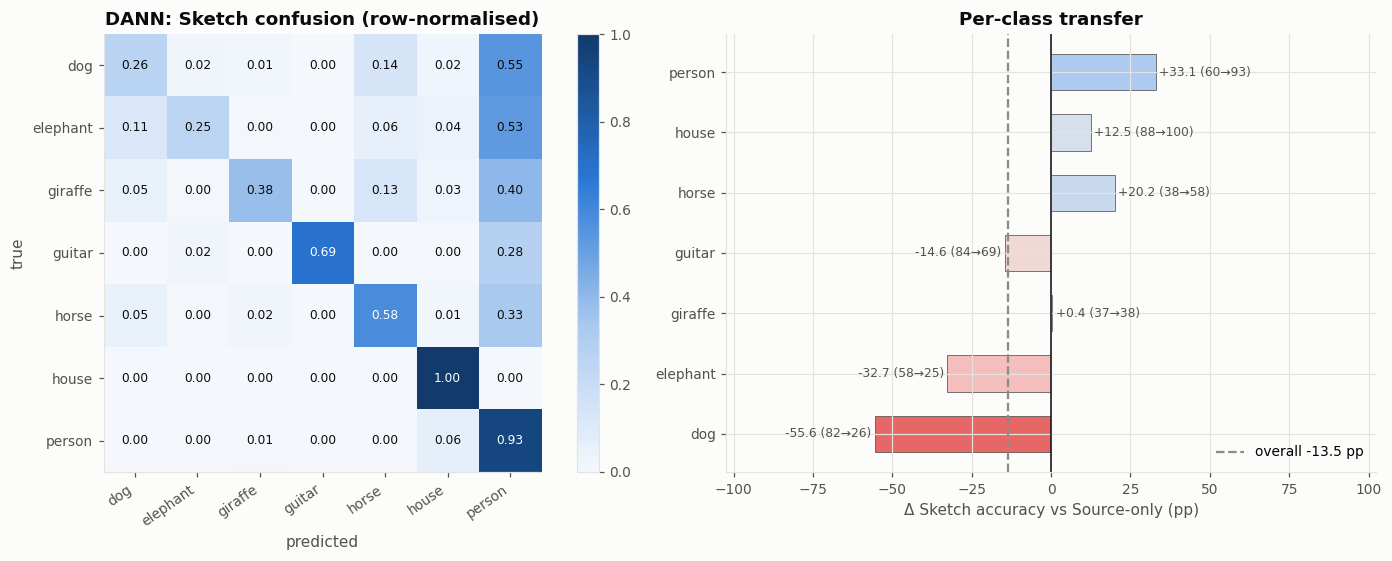

In [8]:
so_model = ResNet18Backbone(num_classes=7).to(device)
so_model.load_state_dict(torch.load(os.path.join(CKPT, 'source_only.pth'), map_location=device, weights_only=True))
so_tgt = evaluate_target(so_model, tgt_eval, device)
pc, pc_so = 100 * np.array(tgt['per_class_acc']), 100 * np.array(so_tgt['per_class_acc'])
dpc = pc - pc_so
cm = tgt['confusion_matrix']; cm_n = cm / cm.sum(1, keepdims=True)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={'width_ratios': [1.1, 1]})
im = a1.imshow(cm_n, cmap=SEQ_CMAP, vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        a1.text(j, i, f"{cm_n[i, j]:.2f}", ha='center', va='center', fontsize=8, color='white' if cm_n[i, j] > 0.55 else '#0b0b0b')
a1.set_xticks(range(7)); a1.set_xticklabels(PACS_CLASSES, rotation=35, ha='right'); a1.set_yticks(range(7)); a1.set_yticklabels(PACS_CLASSES)
a1.set_xlabel('predicted'); a1.set_ylabel('true'); a1.set_title('DANN: Sketch confusion (row-normalised)'); a1.grid(False)
fig.colorbar(im, ax=a1, fraction=0.046)
lim = max(5, np.abs(dpc).max() * 1.15)
cols = [DIV_CMAP(0.5 + 0.5 * v / lim) for v in dpc]
bars = a2.barh(PACS_CLASSES, dpc, color=cols, height=0.6, edgecolor='#52514e', linewidth=0.5)
a2.axvline(0, color='#0b0b0b', lw=1); a2.axvline(delta, color=NEUTRAL, ls='--', lw=1.5, label=f'overall {delta:+.1f} pp')
for b, v, s, t in zip(bars, dpc, pc_so, pc):
    a2.text(v + (1 if v >= 0 else -1), b.get_y() + b.get_height() / 2, f"{v:+.1f} ({s:.0f}→{t:.0f})", va='center', ha='left' if v >= 0 else 'right', fontsize=8, color=INK_2)
a2.set_xlim(-lim * 1.6, lim * 1.6); a2.set_xlabel('Δ Sketch accuracy vs Source-only (pp)'); a2.set_title('Per-class transfer'); a2.legend(loc='lower right')
fig.tight_layout()
save_show(fig, os.path.join(RES, 'dann_target_analysis.png'))